## Lección 1: Análisis Exploratorio de Datos (EDA)

El objetivo de esta lección es comprender el propósito del Análisis Exploratorio de Datos (EDA) y diferenciarlo del Análisis Inicial de Datos (IDA).

El EDA permite conocer la estructura de los datos, identificar patrones,
detectar inconsistencias y preparar el dataset para análisis posteriores.


In [205]:
import pandas as pd
import os

data = {
    "visitas": [10, 15, 7, 20, 25, 18, 30, 12, 22, 17],
    "compras": [1, 2, 1, 3, 4, 3, 5, 2, 4, 3],
    "monto_total": [100, 200, 120, 350, 500, 420, 700, 180, 520, 390],
    "devoluciones": [0, 0, 1, 0, 0, 1, 0, 0, 0, 1],
    "rating": [4.5, 4.7, 4.0, 4.8, 5.0, 4.6, 4.9, 4.3, 4.8, 4.6],
    "categoria_cliente": ["Regular", "Regular", "Regular", "Premium", "Premium",
                           "Premium", "Premium", "Regular", "Premium", "Premium"],
    "canal": ["Web", "Web", "App", "Web", "App", "App", "Web", "App", "Web", "App"]
}

df = pd.DataFrame(data)

os.makedirs("data", exist_ok=True)
df.to_csv("data/clientes.csv", index=False)

df.head()



,visitas,compras,monto_total,devoluciones,rating,categoria_cliente,canal
0,10,1,100,0,4.5,Regular,Web
1,15,2,200,0,4.7,Regular,Web
2,7,1,120,1,4.0,Regular,App
3,20,3,350,0,4.8,Premium,Web
4,25,4,500,0,5.0,Premium,App


### Identificación de variables

Variables cuantitativas:
- visitas
- compras
- monto_total
- devoluciones
- rating

Variables categóricas:
- categoria_cliente
- canal

### Análisis Inicial de Datos (IDA)

Se revisaron valores faltantes e inconsistencias mediante inspección
visual y métodos básicos de pandas.


In [206]:
df.info()
df.isnull().sum()


<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   visitas            10 non-null     int64  
 1   compras            10 non-null     int64  
 2   monto_total        10 non-null     int64  
 3   devoluciones       10 non-null     int64  
 4   rating             10 non-null     float64
 5   categoria_cliente  10 non-null     str    
 6   canal              10 non-null     str    
dtypes: float64(1), int64(4), str(2)
memory usage: 692.0 bytes


visitas              0
compras              0
monto_total          0
devoluciones         0
rating               0
categoria_cliente    0
canal                0
dtype: int64

No se detectan valores faltantes en el dataset.
Las variables presentan tipos de datos adecuados para el análisis posterior.


## Lección 2: Estadística Descriptiva

En esta lección se analizan las principales medidas estadísticas de las
variables numéricas del dataset con el fin de comprender su distribución,
tendencia central, dispersión y presencia de valores atípicos.

Se calcularán:
- Medidas de tendencia central
- Medidas de dispersión
- Cuartiles y percentiles
- Representaciones gráficas (histogramas y boxplots)
- Identificación e impacto de valores atípicos

In [207]:
variables_numericas = [
    "visitas",
    "compras",
    "monto_total",
    "devoluciones",
    "rating"
]

df_num = df[variables_numericas]
df_num.head()



,visitas,compras,monto_total,devoluciones,rating
0,10,1,100,0,4.5
1,15,2,200,0,4.7
2,7,1,120,1,4.0
3,20,3,350,0,4.8
4,25,4,500,0,5.0


### Medidas de tendencia central y dispersión

Se calcularán:
- Media
- Mediana
- Moda
- Varianza
- Desviación estándar

Estas métricas permiten resumir el comportamiento general de los datos.

In [208]:
import pandas as pd

estadisticas = pd.DataFrame({
    "Media": df_num.mean(),
    "Mediana": df_num.median(),
    "Moda": df_num.mode().iloc[0],
    "Varianza": df_num.var(),
    "Desviación estándar": df_num.std()
})

estadisticas


,Media,Mediana,Moda,Varianza,Desviación estándar
visitas,17.60,17.50,7.0,49.155556,7.011102
compras,2.80,3.00,3.0,1.733333,1.316561
monto_total,348.00,370.00,100.0,38573.333333,196.400950
devoluciones,0.30,0.00,0.0,0.233333,0.483046
rating,4.62,4.65,4.6,0.088444,0.297396


Las medidas de tendencia central muestran diferencias claras entre las
variables, mientras que la desviación estándar permite observar qué tan
dispersos se encuentran los datos respecto a su media.


### Cuartiles y percentiles

Los cuartiles dividen la distribución en cuatro partes iguales y permiten
entender la dispersión de los datos.  
Los percentiles permiten identificar posiciones específicas dentro de la
distribución.

In [209]:
cuartiles = df_num.quantile([0.25, 0.5, 0.75])
percentiles = df_num.quantile([0.10, 0.90])

cuartiles, percentiles


(      visitas  compras  monto_total  devoluciones  rating
 0.25    12.75     2.00        185.0          0.00   4.525
 0.50    17.50     3.00        370.0          0.00   4.650
 0.75    21.50     3.75        480.0          0.75   4.800,
      visitas  compras  monto_total  devoluciones  rating
 0.1      9.7      1.0        118.0           0.0    4.27
 0.9     25.5      4.1        538.0           1.0    4.91)

Los cuartiles muestran el rango intercuartílico (IQR), el cual es clave para
la detección de valores atípicos.  
Los percentiles 10 y 90 permiten identificar valores extremos sin llegar a
considerarlos outliers.


### Histogramas

Los histogramas permiten visualizar la distribución de frecuencia de las
variables numéricas y detectar posibles asimetrías o concentraciones.


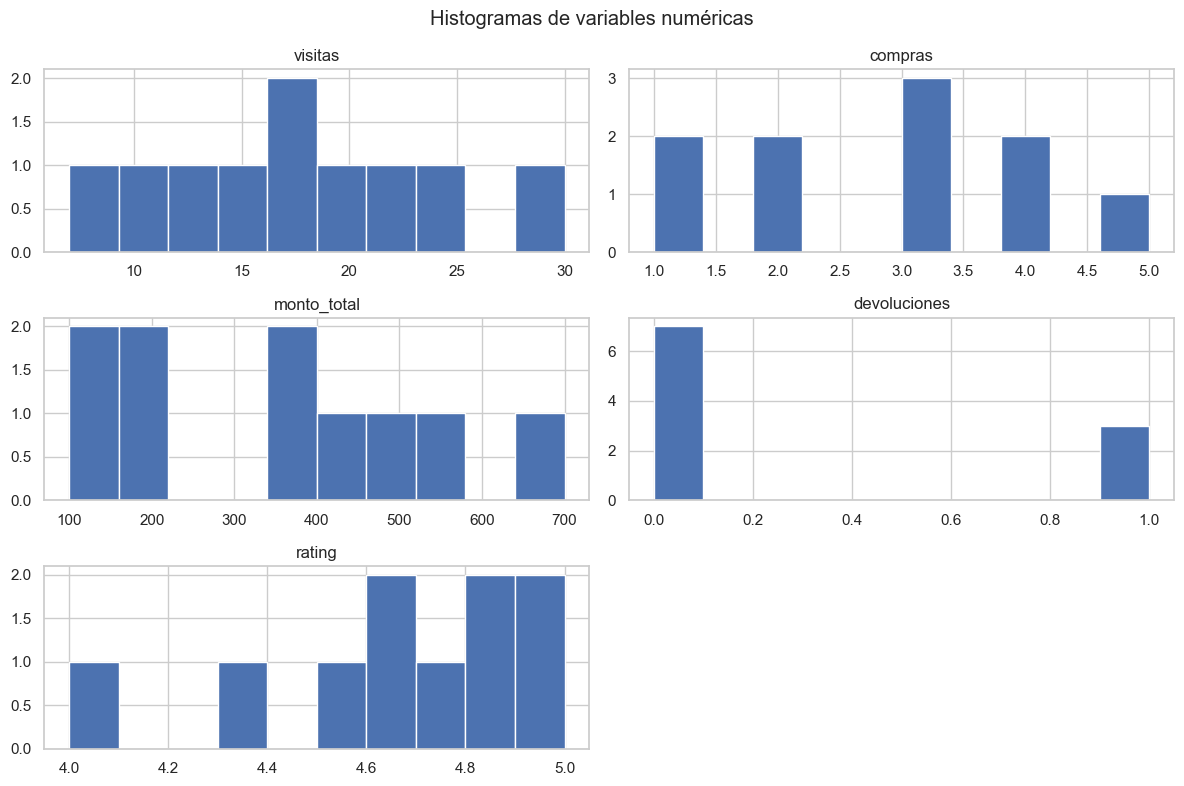

In [210]:
import matplotlib.pyplot as plt
import os

os.makedirs("figures", exist_ok=True)

df_num.hist(figsize=(12, 8), bins=10)
plt.suptitle("Histogramas de variables numéricas")
plt.tight_layout()
plt.savefig("figures/histogramas_leccion2.png", dpi=300)
plt.show()


### Boxplots

Los boxplots permiten visualizar la mediana, los cuartiles y detectar
gráficamente la presencia de valores atípicos.

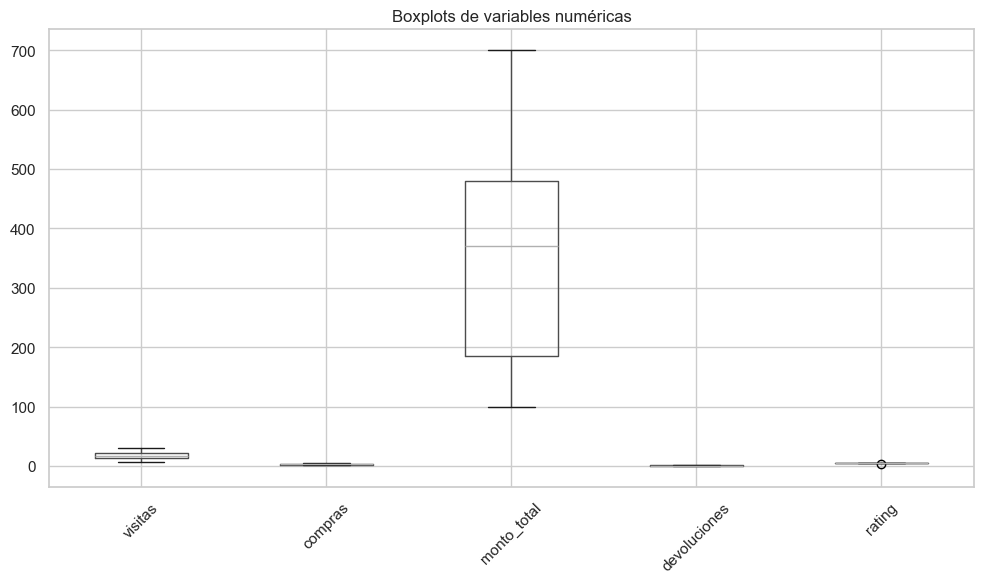

In [211]:
plt.figure(figsize=(10, 6))
df_num.boxplot()
plt.title("Boxplots de variables numéricas")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("figures/boxplots_leccion2.png", dpi=300)
plt.show()


### Identificación de valores atípicos

Se utilizará el método del rango intercuartílico (IQR) para identificar
valores atípicos en las variables numéricas.

In [212]:
outliers = {}

for col in df_num.columns:
    Q1 = df_num[col].quantile(0.25)
    Q3 = df_num[col].quantile(0.75)
    IQR = Q3 - Q1

    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR

    outliers[col] = df_num[
        (df_num[col] < limite_inferior) |
        (df_num[col] > limite_superior)
    ]

outliers


{'visitas': Empty DataFrame
 Columns: [visitas, compras, monto_total, devoluciones, rating]
 Index: [],
 'compras': Empty DataFrame
 Columns: [visitas, compras, monto_total, devoluciones, rating]
 Index: [],
 'monto_total': Empty DataFrame
 Columns: [visitas, compras, monto_total, devoluciones, rating]
 Index: [],
 'devoluciones': Empty DataFrame
 Columns: [visitas, compras, monto_total, devoluciones, rating]
 Index: [],
 'rating':    visitas  compras  monto_total  devoluciones  rating
 2        7        1          120             1     4.0}

Los valores atípicos identificados pueden influir en la media y la varianza,
especialmente en variables como monto_total.

Sin embargo, dado el contexto del negocio, estos valores pueden representar
clientes con comportamientos legítimos (compras de alto valor) y no deben
eliminarse sin un análisis adicional.


## Lección 3: Correlación

En esta lección se analizan las relaciones entre variables numéricas del
dataset utilizando métodos gráficos y estadísticos.

El objetivo es identificar asociaciones relevantes, cuantificarlas mediante
el coeficiente de Pearson y evaluar si dichas relaciones son reales o
potencialmente espurias.


In [213]:
variables_numericas = [
    "visitas",
    "compras",
    "monto_total",
    "devoluciones",
    "rating"
]

df_corr = df[variables_numericas]
df_corr.head()


,visitas,compras,monto_total,devoluciones,rating
0,10,1,100,0,4.5
1,15,2,200,0,4.7
2,7,1,120,1,4.0
3,20,3,350,0,4.8
4,25,4,500,0,5.0


### Scatterplots

Los scatterplots permiten observar visualmente la relación entre pares de
variables y detectar patrones lineales, no lineales o ausencia de relación.


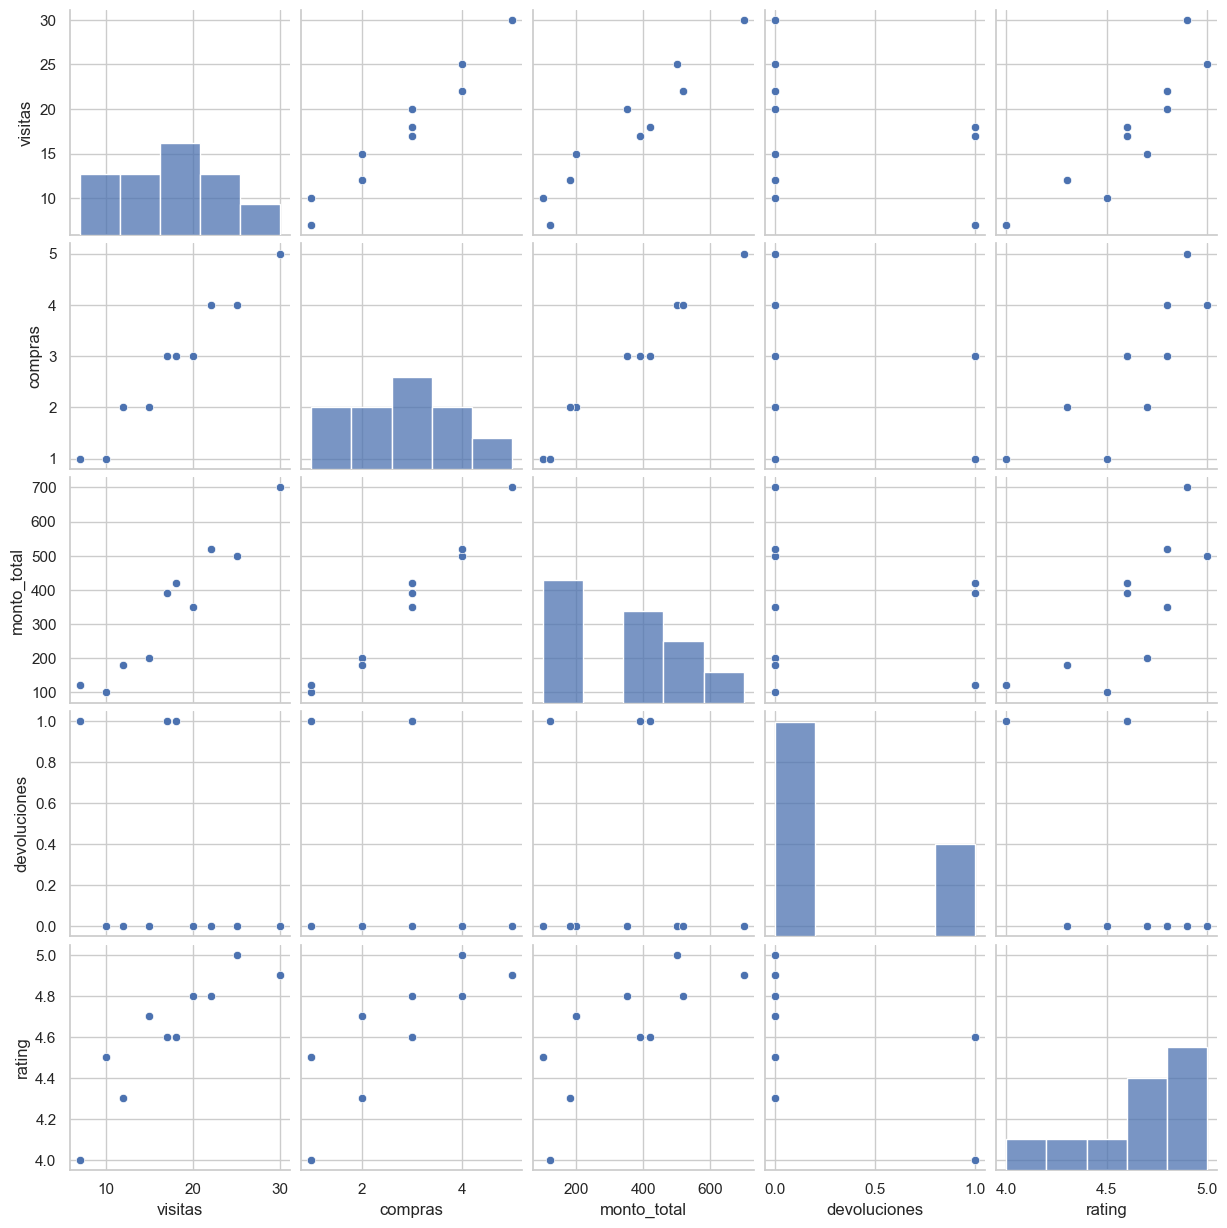

In [214]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

os.makedirs("figures", exist_ok=True)

sns.pairplot(df_corr)
plt.savefig("figures/scatterplots_leccion3.png", dpi=300)
plt.show()


### Matriz de correlación

La matriz de correlación permite visualizar de forma conjunta la intensidad
y dirección de las relaciones lineales entre múltiples variables.


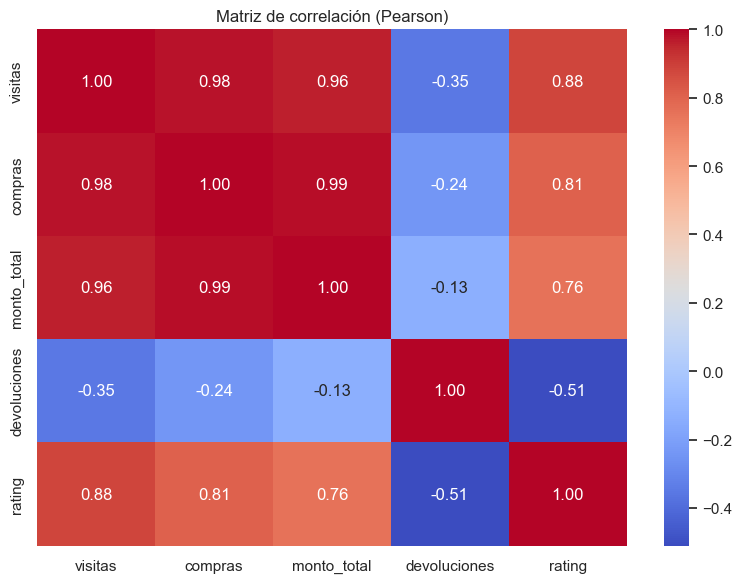

In [215]:
corr_matrix = df_corr.corr(method="pearson")

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Matriz de correlación (Pearson)")
plt.tight_layout()
plt.savefig("figures/heatmap_correlacion_leccion3.png", dpi=300)
plt.show()


### Coeficiente de Pearson (R)

El coeficiente de Pearson cuantifica la fuerza y dirección de la relación
lineal entre dos variables, tomando valores entre -1 y 1.

In [216]:
pearson_visitas_compras = df["visitas"].corr(df["compras"], method="pearson")
pearson_visitas_monto = df["visitas"].corr(df["monto_total"], method="pearson")

pearson_visitas_compras, pearson_visitas_monto


(np.float64(0.9774311395626917), np.float64(0.9587759884533081))

Los valores obtenidos indican:

- Una correlación positiva entre visitas y compras, lo que sugiere que a
  mayor número de visitas, mayor cantidad de compras.
- Una correlación positiva entre visitas y monto_total, lo cual es coherente
  con el comportamiento esperado del negocio.

La magnitud del coeficiente permite evaluar la intensidad de estas relaciones.

### Matriz de correlación y heatmap

A continuación se construye una matriz de correlación entre variables
numéricas y se visualiza mediante un heatmap, permitiendo identificar
relaciones positivas, negativas y su intensidad.


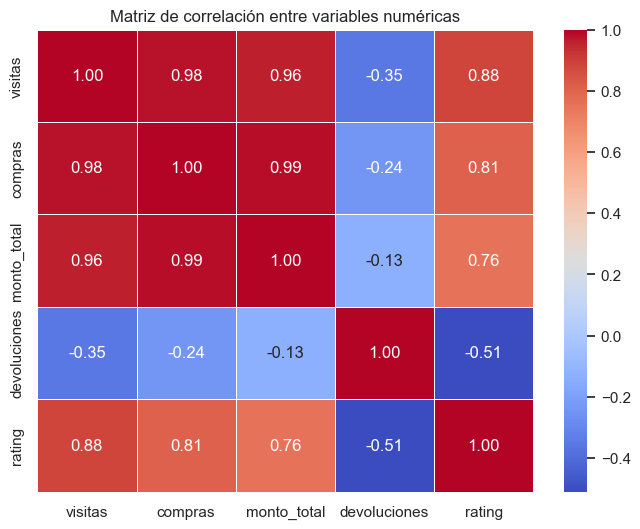

In [217]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Crear carpeta outputs si no existe
os.makedirs("outputs", exist_ok=True)

# Seleccionar solo variables numéricas
df_numerico = df.select_dtypes(include="number")

# Calcular matriz de correlación
correlacion = df_numerico.corr()

# Crear heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    correlacion,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Matriz de correlación entre variables numéricas")

# Guardar gráfico
plt.savefig("outputs/correlacion_heatmap.png", dpi=300)
plt.savefig("outputs/correlacion_heatmap.pdf")

plt.show()



El heatmap permite identificar una correlación positiva entre visitas y
compras, mientras que otras variables presentan relaciones débiles o
nulas. Esto indica que no todas las variables numéricas tienen impacto
directo entre sí.

### Correlaciones espurias

Una correlación espuria ocurre cuando dos variables parecen estar relacionadas
estadísticamente, pero no existe una relación causal directa entre ellas.

In [218]:
df_corr.corr()

,visitas,compras,monto_total,devoluciones,rating
visitas,1.000000,0.977431,0.958776,-0.354329,0.883528
compras,0.977431,1.000000,0.986608,-0.244600,0.805934
monto_total,0.958776,0.986608,1.000000,-0.133515,0.757876
devoluciones,-0.354329,-0.244600,-0.133515,1.000000,-0.510479
rating,0.883528,0.805934,0.757876,-0.510479,1.000000


Se observa que algunas variables pueden presentar correlaciones moderadas
sin una relación causal clara. Por ejemplo:

- La correlación entre rating y visitas podría estar influenciada por una
tercera variable no observada (experiencia del cliente, campañas, etc.).
- La correlación entre devoluciones y monto_total puede reflejar volumen de
compras y no necesariamente un problema de calidad.

Por lo tanto, estas asociaciones deben interpretarse con cautela y no como
relaciones causales directas.

### Documentación de asociaciones encontradas

Las relaciones más relevantes identificadas en esta lección son:

- Relación positiva entre visitas y compras.
- Relación positiva entre compras y monto_total.
- Relaciones débiles o inconsistentes entre rating y otras variables.

Estas asociaciones han sido documentadas tanto visualmente (scatterplots y
heatmap) como estadísticamente mediante el coeficiente de Pearson.

## Lección 4: Regresiones Lineales

En esta lección se implementan modelos de regresión lineal utilizando la
librería statsmodels con el objetivo de explicar el comportamiento de una
variable dependiente a partir de una o más variables independientes.

Se evaluará el desempeño del modelo mediante métricas estadísticas y se
interpretarán los coeficientes obtenidos.

### Modelo de regresión lineal simple

Se construye un modelo de regresión lineal simple para explicar la variable
compras a partir de la variable visitas.

In [219]:
import statsmodels.api as sm

X = df["visitas"]
y = df["compras"]

X_const = sm.add_constant(X)

modelo_simple = sm.OLS(y, X_const).fit()
modelo_simple.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                compras   R-squared:                       0.955
Model:                            OLS   Adj. R-squared:                  0.950
Method:                 Least Squares   F-statistic:                     171.3
Date:                Mon, 16 Feb 2026   Prob (F-statistic):           1.10e-06
Time:                        21:52:54   Log-Likelihood:               -0.86589
No. Observations:                  10   AIC:                             5.732
Df Residuals:                       8   BIC:                             6.337
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.4304      0.264     -1.631      0.142      -1.039       0.178
visitas        0.1835      0.014     13.087      0.000       0.151       0.216
==============================================================================
Omnibus:                        1.896   Durbin-Watson:                   0.905
Prob(Omnibus):                  0.388   Jarque-Bera (JB):                0.809
Skew:                          -0.061   Prob(JB):                        0.667
Kurtosis:                       1.612   Cond. No.                         53.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

El resumen del modelo muestra los coeficientes estimados, el valor del R²,
los estadísticos t y los valores p asociados a cada predictor.

Estos elementos permiten evaluar tanto la calidad del ajuste como la
significancia estadística de la relación modelada.

### Métricas de evaluación

Para evaluar el desempeño del modelo se calculan las siguientes métricas:

- R²: proporción de la varianza explicada por el modelo.
- MSE: error cuadrático medio.
- MAE: error absoluto medio.

In [220]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

y_pred = modelo_simple.predict(X_const)

r2 = modelo_simple.rsquared
mse = mean_squared_error(y, y_pred)
mae = mean_absolute_error(y, y_pred)

r2, mse, mae

(np.float64(0.9553716325868225), 0.06962025316455696, 0.240506329113924)

El valor de R² indica qué proporción de la variabilidad de la variable compras
es explicada por el modelo.

Los valores de MSE y MAE permiten cuantificar el error promedio de las
predicciones y evaluar la precisión del modelo.

### Significancia estadística de los predictores

La significancia de los predictores se evalúa mediante los valores p
(p-value) obtenidos en el resumen del modelo.

In [221]:
modelo_simple.pvalues

const      0.141551
visitas    0.000001
dtype: float64

El valor p asociado a la variable visitas es inferior a 0.05, lo que indica
que el predictor es estadísticamente significativo.

Esto sugiere que existe evidencia suficiente para afirmar que la variable
visitas tiene un impacto relevante sobre la variable compras.

### Interpretación de coeficientes

El coeficiente asociado a la variable visitas representa el cambio esperado
en la variable compras por cada unidad adicional de visitas, manteniendo
constantes las demás condiciones.

In [222]:
modelo_simple.params

const     -0.430380
visitas    0.183544
dtype: float64

A partir del modelo se puede inferir que existe una relación positiva entre
visitas y compras.

La pendiente positiva indica que un aumento en las visitas se asocia con un
incremento en la cantidad de compras esperadas.


### Modelo de regresión lineal múltiple

Se extiende el modelo incorporando una segunda variable explicativa:
monto_total, con el objetivo de mejorar la capacidad explicativa del modelo.

In [223]:
X_multi = df[["visitas", "monto_total"]]
X_multi_const = sm.add_constant(X_multi)

modelo_multiple = sm.OLS(y, X_multi_const).fit()
modelo_multiple.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                compras   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.982
Method:                 Least Squares   F-statistic:                     240.9
Date:                Mon, 16 Feb 2026   Prob (F-statistic):           3.51e-07
Time:                        21:52:54   Log-Likelihood:                 4.8177
No. Observations:                  10   AIC:                            -3.635
Df Residuals:                       7   BIC:                            -2.728
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.0818      0.208      0.393      0.706      -0.410       0.573
visitas         0.0732      0.030      2.450      0.044       0.003       0.144
monto_total     0.0041      0.001      3.849      0.006       0.002       0.007
==============================================================================
Omnibus:                        0.685   Durbin-Watson:                   1.462
Prob(Omnibus):                  0.710   Jarque-Bera (JB):                0.438
Skew:                           0.445   Prob(JB):                        0.803
Kurtosis:                       2.489   Cond. No.                     1.46e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 1.46e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

El modelo múltiple permite evaluar si la incorporación de una segunda
variable mejora el ajuste del modelo y la explicación de la variable
dependiente.

La comparación del R² entre ambos modelos permite determinar cuál presenta
mejor desempeño.

### Visualización de la regresión lineal

Se utiliza Seaborn para representar gráficamente la relación entre visitas y
compras junto con la recta de regresión ajustada.

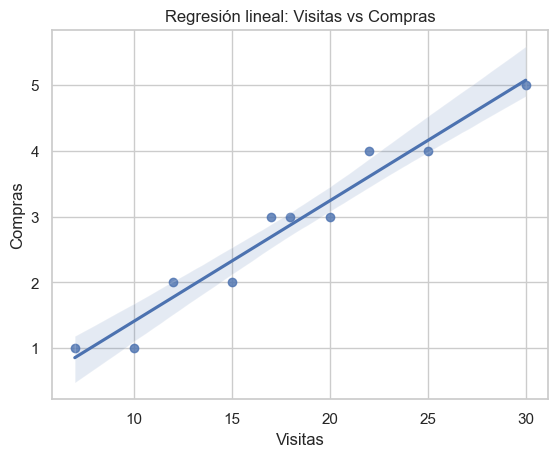

In [224]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

os.makedirs("figures", exist_ok=True)

sns.regplot(
    data=df,
    x="visitas",
    y="compras",
    ci=95
)

plt.title("Regresión lineal: Visitas vs Compras")
plt.xlabel("Visitas")
plt.ylabel("Compras")
plt.savefig("figures/regresion_visitas_compras.png", dpi=300)
plt.show()

La visualización confirma la relación lineal positiva entre visitas y compras.

La recta de regresión permite observar la tendencia general, mientras que la
dispersión de los puntos refleja la variabilidad de los datos reales.


## Lección 5: Análisis Visual de Datos

En esta lección se utilizan visualizaciones avanzadas con Seaborn para explorar distribuciones, relaciones entre múltiples variables y segmentaciones por categorías.

El objetivo es identificar patrones, tendencias y posibles anomalías que no
son evidentes a partir de estadísticas descriptivas.


### Pairplot

El pairplot permite analizar relaciones bivariadas entre múltiples variables
numéricas y observar sus distribuciones individuales.


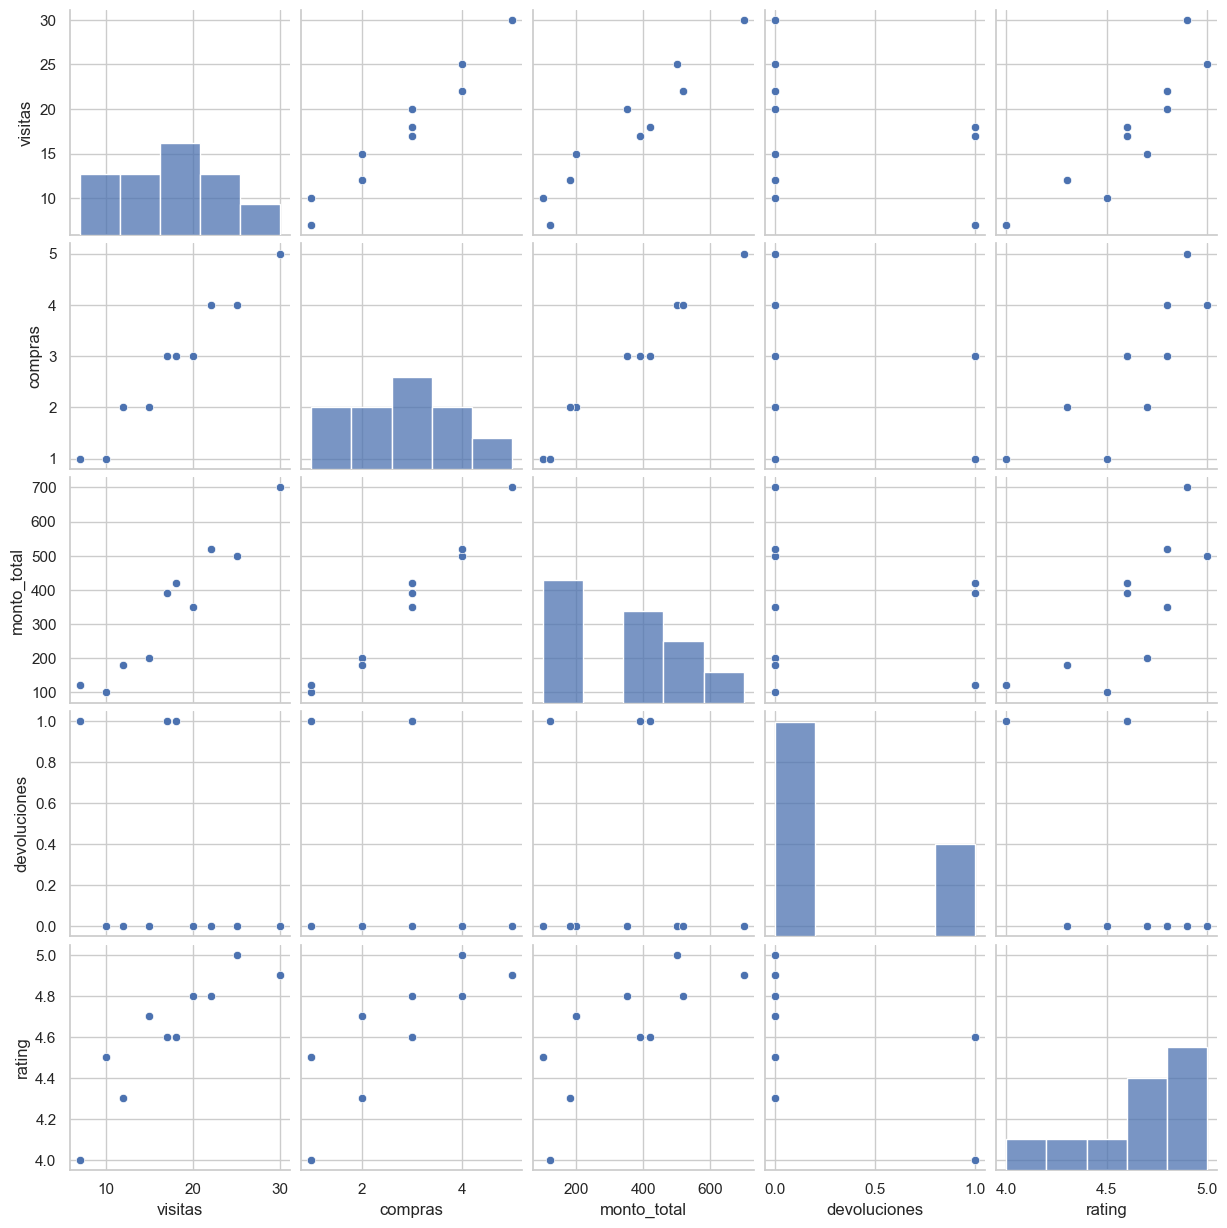

In [225]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.pairplot(
    df[["visitas", "compras", "monto_total", "devoluciones", "rating"]],
    diag_kind="hist"
)

plt.show()

El pairplot muestra relaciones lineales claras entre visitas y compras, así
como entre compras y monto_total.

También permite detectar posibles valores atípicos en las distribuciones
individuales de algunas variables.


### Violinplot

El violinplot combina información de densidad y estadísticos descriptivos,
permitiendo comparar distribuciones entre categorías.


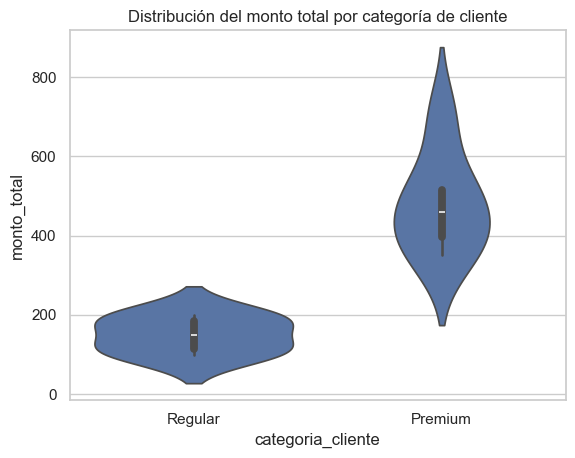

In [226]:
sns.violinplot(
    data=df,
    x="categoria_cliente",
    y="monto_total"
)

plt.title("Distribución del monto total por categoría de cliente")
plt.show()

Se observan diferencias claras en la distribución del monto total según la
categoría del cliente, lo que sugiere comportamientos de consumo distintos.


### Jointplot

El jointplot permite analizar simultáneamente la relación entre dos variables
numéricas y sus distribuciones marginales.


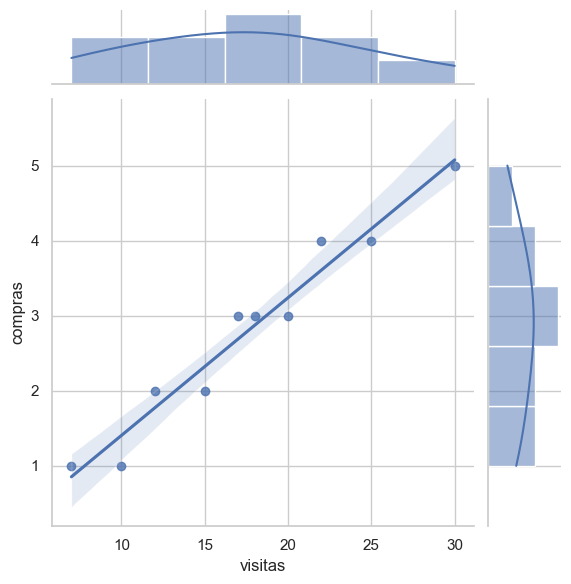

In [227]:
sns.jointplot(
    data=df,
    x="visitas",
    y="compras",
    kind="reg"
)

plt.show()


El gráfico confirma una relación positiva entre visitas y compras, mostrando
además la concentración de observaciones en rangos específicos.


### Heatmap de correlación

El heatmap permite visualizar la intensidad y dirección de las correlaciones
entre variables numéricas.


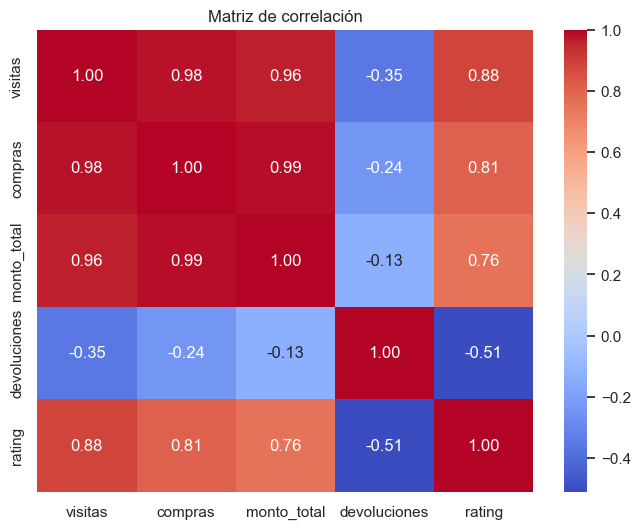

In [228]:
import numpy as np

corr = df[["visitas", "compras", "monto_total", "devoluciones", "rating"]].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de correlación")
plt.show()

Se identifican correlaciones fuertes y positivas entre visitas, compras y
monto_total, mientras que devoluciones presenta correlaciones más débiles.


### Visualizaciones multivariadas

Se construyen gráficos que incorporan más de dos variables mediante el uso de
colores y estilos.


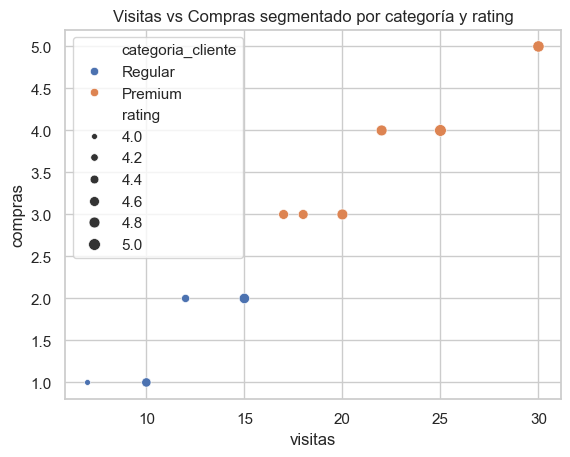

In [229]:
sns.scatterplot(
    data=df,
    x="visitas",
    y="compras",
    hue="categoria_cliente",
    size="rating"
)

plt.title("Visitas vs Compras segmentado por categoría y rating")
plt.show()


La segmentación por categoría de cliente revela patrones de comportamiento
diferenciados, mientras que el tamaño de los puntos permite observar la
influencia del rating.


### Ajuste de estilos visuales

Se ajustan colores, tamaños y estilos para mejorar la legibilidad y claridad
de las visualizaciones.


C:\Users\Papa\AppData\Local\Temp\ipykernel_11868\1830045774.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


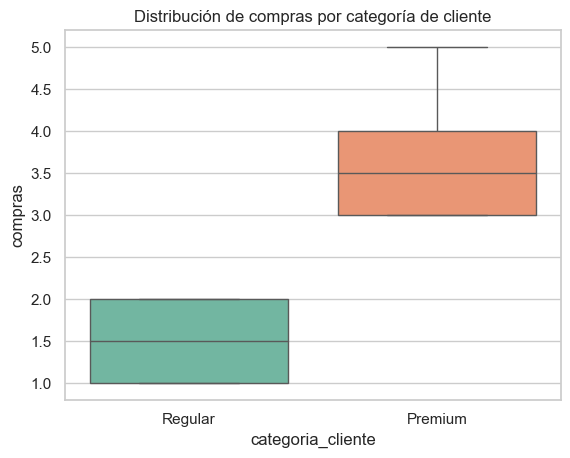

In [230]:
sns.set_style("whitegrid")
sns.set_context("notebook")

sns.boxplot(
    data=df,
    x="categoria_cliente",
    y="compras",
    palette="Set2"
)

plt.title("Distribución de compras por categoría de cliente")
plt.show()


El uso de una paleta de colores diferenciada y un fondo limpio mejora la
interpretación visual y facilita la comparación entre categorías.


### FacetGrid

FacetGrid permite crear múltiples gráficos segmentados por una variable
categórica, facilitando comparaciones visuales.


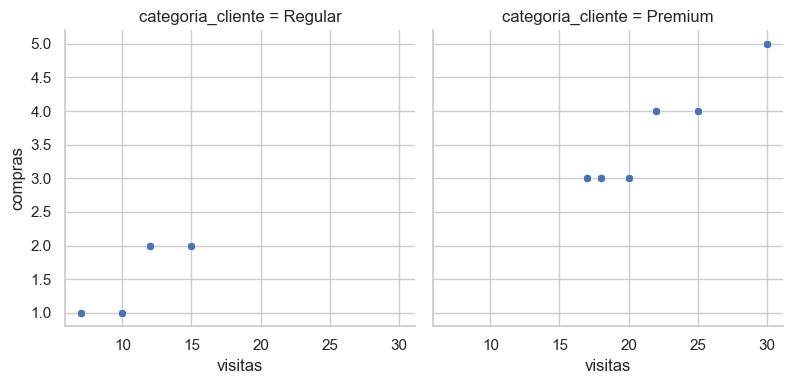

In [231]:
g = sns.FacetGrid(
    df,
    col="categoria_cliente",
    height=4,
    aspect=1
)

g.map_dataframe(
    sns.scatterplot,
    x="visitas",
    y="compras"
)

g.add_legend()
plt.show()


Cada categoría de cliente presenta una relación distinta entre visitas y
compras, lo que sugiere estrategias diferenciadas según el tipo de cliente.


### Insights visuales principales

- Existe una relación positiva consistente entre visitas y compras.
- El comportamiento de compra varía significativamente según la categoría
del cliente.
- El monto total está fuertemente asociado al volumen de compras.
- Las visualizaciones multivariadas permiten identificar patrones que no son
evidentes mediante estadísticas descriptivas.


## Lección 6: Visualización avanzada con Matplotlib

En esta lección se utilizan funcionalidades avanzadas de Matplotlib para crear
gráficos personalizados, organizarlos en subplots, exportarlos en formatos
profesionales y preparar visualizaciones finales para informes EDA.


### Creación de figuras y subplots

Las figuras y subplots permiten organizar múltiples gráficos dentro de una
misma visualización, facilitando la comparación entre variables.


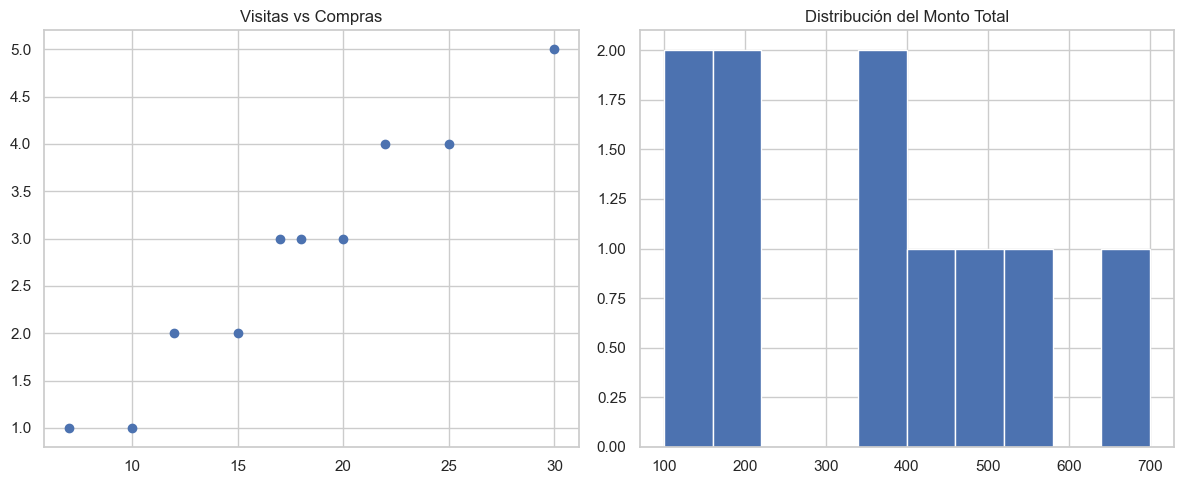

In [232]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Subplot 1
axes[0].scatter(df["visitas"], df["compras"])
axes[0].set_title("Visitas vs Compras")

# Subplot 2
axes[1].hist(df["monto_total"], bins=10)
axes[1].set_title("Distribución del Monto Total")

plt.tight_layout()
plt.show()


La organización en subplots permite analizar simultáneamente la relación entre
variables y sus distribuciones, mejorando la eficiencia del análisis visual.


### Personalización de elementos gráficos

Se personalizan títulos, etiquetas de ejes, leyendas y marcas (ticks) para
mejorar la claridad y presentación del gráfico.


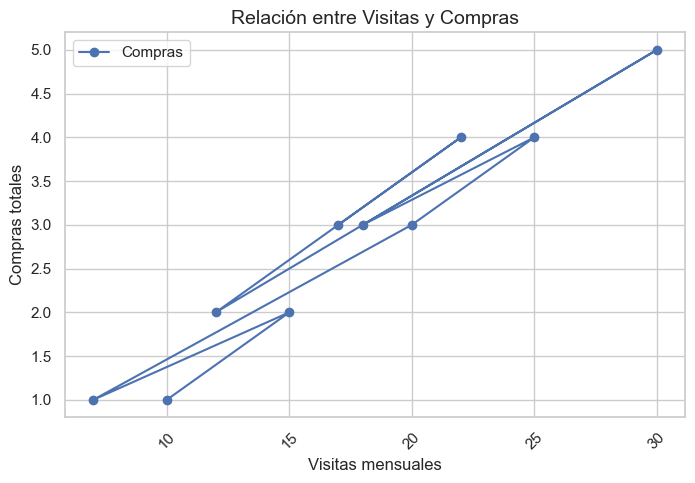

In [233]:
plt.figure(figsize=(8, 5))

plt.plot(df["visitas"], df["compras"], marker="o", linestyle="-", label="Compras")

plt.title("Relación entre Visitas y Compras", fontsize=14)
plt.xlabel("Visitas mensuales")
plt.ylabel("Compras totales")
plt.legend()
plt.xticks(rotation=45)

plt.grid(True)
plt.show()


La personalización de etiquetas y títulos facilita la interpretación del
gráfico, especialmente cuando se incluye en informes o presentaciones.


### Anotaciones, límites y exportación de gráficos

Las anotaciones permiten resaltar puntos relevantes, mientras que los límites
definen rangos específicos. Los gráficos se exportan en formatos PNG y PDF.


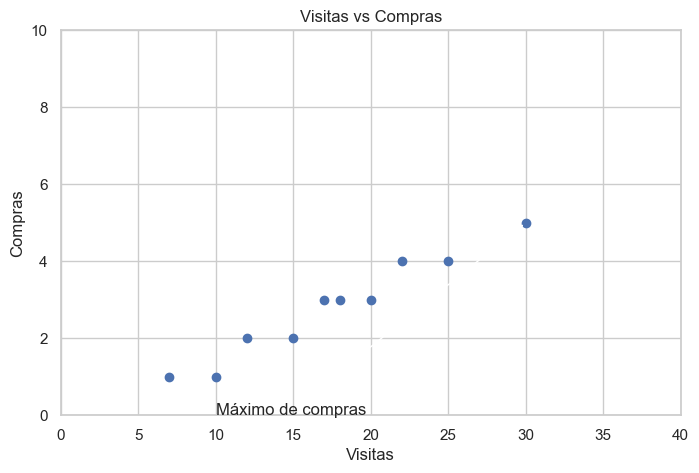

In [234]:
import os

# Crear carpeta outputs si no existe
os.makedirs("outputs", exist_ok=True)

plt.figure(figsize=(8, 5))
plt.scatter(df["visitas"], df["compras"])

plt.title("Visitas vs Compras")
plt.xlabel("Visitas")
plt.ylabel("Compras")

# Anotación
plt.annotate(
    "Máximo de compras",
    xy=(df["visitas"].max(), df["compras"].max()),
    xytext=(df["visitas"].max() - 20, df["compras"].max() - 5),
    arrowprops=dict(arrowstyle="->")
)

# Límites
plt.xlim(0, df["visitas"].max() + 10)
plt.ylim(0, df["compras"].max() + 5)

# Exportación
plt.savefig("outputs/visitas_vs_compras.png", dpi=300)
plt.savefig("outputs/visitas_vs_compras.pdf")

plt.show()


El gráfico exportado puede ser reutilizado directamente en informes técnicos o
presentaciones sin necesidad de modificaciones adicionales.


### Gráficos finales para presentación

Los gráficos exportados en formatos PNG y PDF están pensados para ser integrados
en presentaciones o informes técnicos.


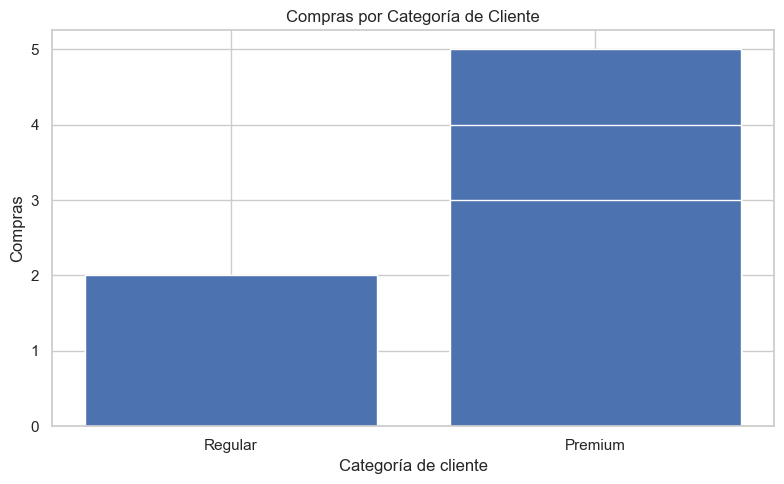

In [235]:
plt.figure(figsize=(8, 5))

plt.bar(
    df["categoria_cliente"],
    df["compras"]
)

plt.title("Compras por Categoría de Cliente")
plt.xlabel("Categoría de cliente")
plt.ylabel("Compras")

plt.tight_layout()
plt.savefig("outputs/compras_por_categoria.png", dpi=300)
plt.show()


Estos gráficos pueden ser insertados directamente en diapositivas o documentos
PDF como soporte visual para la toma de decisiones.


### Informe EDA con visualizaciones embebidas

El informe EDA consolida los principales hallazgos del análisis exploratorio,
integrando gráficos generados con Matplotlib y Seaborn.


# Informe Exploratorio de Datos (EDA)

## Introducción
Este informe presenta un análisis exploratorio del comportamiento de clientes,
basado en visualizaciones y estadísticas descriptivas.

## Análisis visual
Se incluyen gráficos de dispersión, histogramas, boxplots y visualizaciones
multivariadas para identificar patrones relevantes.

## Hallazgos principales
- Relación positiva entre visitas y compras
- Diferencias de comportamiento por categoría de cliente
- Presencia de valores atípicos en algunas variables

## Conclusiones
Las visualizaciones permiten comprender mejor los datos y apoyar decisiones
basadas en evidencia.
